In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/scoring.csv')
df.head()

,age,income,education,work,car,default
0,27,32,0,0,1,0
1,26,50,1,0,0,0
2,35,20,0,1,0,0
3,35,80,1,1,0,0
4,24,27,0,0,0,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>],
       [<Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'work'}>],
       [<Axes: title={'center': 'car'}>,
        <Axes: title={'center': 'default'}>]], dtype=object)

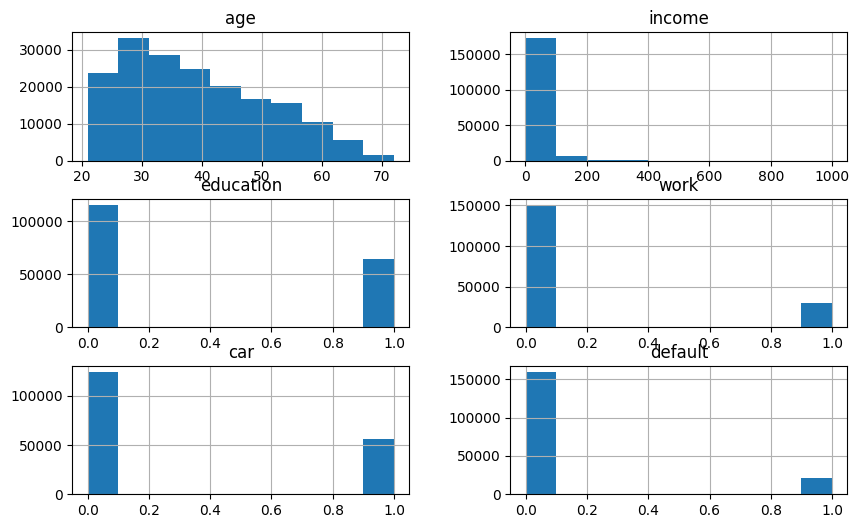

In [3]:
df.hist(figsize=(10, 6))

In [4]:
# Логарифм дохода
df['log_income'] = np.log1p(df['income'])

# Взаимодействия признаков
df["income_per_age"] = df["income"] / df["age"]
df["employed_educated"] = df["work"] * df["education"]

# Возратсные группы - чем моложе, тем выше риск, но и с выходом на пенсии также доходы падают, что значит снижается платежеспособность
df["age_sq"] = df["age"] ** 2

In [5]:
df

,age,income,education,work,car,default,log_income,income_per_age,employed_educated,age_sq
0,27,32,0,0,1,0,3.496508,1.185185,0,729
1,26,50,1,0,0,0,3.931826,1.923077,0,676
2,35,20,0,1,0,0,3.044522,0.571429,0,1225
3,35,80,1,1,0,0,4.394449,2.285714,1,1225
4,24,27,0,0,0,0,3.332205,1.125000,0,576
...,...,...,...,...,...,...,...,...,...,...
180088,60,90,1,0,1,0,4.510860,1.500000,0,3600
180089,32,25,1,0,1,1,3.258097,0.781250,0,1024
180090,26,35,0,0,1,0,3.583519,1.346154,0,676
180091,28,23,0,0,1,0,3.178054,0.821429,0,784


In [6]:
df.describe()

,age,income,education,work,car,default,log_income,income_per_age,employed_educated,age_sq
count,180093.00000,180093.000000,180093.000000,180093.000000,180093.000000,180093.000000,180093.000000,180093.000000,180093.000000,180093.000000
mean,39.32044,40.837290,0.359964,0.165487,0.310612,0.115252,3.481712,1.130829,0.090048,1679.038097
std,11.53004,43.135917,0.479991,0.371620,0.462745,0.319326,0.664472,1.167386,0.286251,980.641211
min,21.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.015873,0.000000,441.000000
25%,30.00000,20.000000,0.000000,0.000000,0.000000,0.000000,3.044522,0.511111,0.000000,900.000000
50%,37.00000,30.000000,0.000000,0.000000,0.000000,0.000000,3.433987,0.853659,0.000000,1369.000000
75%,48.00000,49.000000,1.000000,0.000000,1.000000,0.000000,3.912023,1.363636,0.000000,2304.000000
max,72.00000,1000.000000,1.000000,1.000000,1.000000,1.000000,6.908755,36.538462,1.000000,5184.000000


In [7]:
df.to_csv("data/scoring_features.csv", index=False)